In [2]:
!hostname

n-62-12-19


In [7]:
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, display, clear_output
import numpy as np
%matplotlib nbagg
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")
sns.set_palette(sns.dark_palette("purple"))

import os
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))

import os
os.chdir('/zhome/3b/1/169159/02456-2025/Week7 Unsupervised')

try:
    from plotting import plot_autoencoder_stats
except Exception as ex:
    print(f"Error importing plotting: {ex}")

Current working directory: /zhome/3b/1/169159/02456-2025
Files in current directory: ['static_files', 'README.md', 'Week1 Feedforward Pen and Paper', 'Week8 Mini Project', 'Week4 Convolutional', 'Week7 Unsupervised', 'Week2 Feedforward Python', 'Week3 Feedforward PyTorch', '.gitignore', 'data', '.git', 'Week6 Transformers', 'Week5 Recurrent', 'Slides']


# Unsupservised Learning 

## Labelling Data is Expensive

In supervised machine learning, one aims at learning a mapping $f_{\psi} : \mathbf{x} \in \mathcal{R}^P \rightarrow \mathbf{y}$ from observations $\mathbf{x}$ to the target $\mathbf{y}$ using a dataset $\mathcal{D} = \{\mathbf{x}_i, \mathbf{y}_i\}_{i=1, \dots, N}$ of finite size N (e.g. image classification, translation). Because of the curse of dimensionality, high-dimensional inputs (images) and complex the models (deep learning) require large datasets (million of pairs $(\mathbf{x}, \mathbf{y})$). In practice, labelling data is expensive (e.g. marking the presence of cancer in X-ray chest scans). 

## Compression is Comprehension: Learning without Target

In order to overcome the curse of dimensionality, we aim at learning a compressed representation $\mathbf{z} \in \mathcal{R}^M$ of $\mathbf{x}$ such that $M < P$ and there is a mapping $g_{\phi}: \mathbf{x} \rightarrow \mathbf{z}$ linking each data point to its representation. Ideally, $\mathbf{z}$ is low-dimensional set of features which efficiently describes $\mathbf{x}$. As an illustration, when modelling pictures of celebrities (CelebA dataset), the set of facial features (eye color, age, hair lenth, etc.) is a compressed (and lossy) representation of $\mathbf{x}$. In practice, the representation  $\mathbf{z}$ is unobservable and [unlikely to overlap with such known features](https://arxiv.org/abs/1811.12359). Yet, the representation $\mathbf{z}$ is low dimensional and learning a mapping $f_{\psi} : \mathbf{z} \in \mathcal{R}^M \rightarrow \mathbf{y}$ is often easier.

Whereas labelling the data is expensive, observations $\mathbf{x}$ are cheap to acquire. In many cases, one can scrap the web to gather a large collection of images or text. As a result, large deep learning models can be deployed to learn $g_{\phi}$, and smaller / data-efficient models can be applied downstream to solve the supervised task.



# Auto-encoders: Compression as a Generation Process
In this notebook you will implement a simple auto-encoder (AE). We assume that you are already familiar with the basics of neural networks. We will start by defining an AE similar to the one used for the finetuning step by [Geoffrey Hinton and Ruslan Salakhutdinov](https://www.cs.toronto.edu/~hinton/science.pdf). We will experiment with the AE setup and try to run it on the MNIST dataset. There has been a wide variety of research into the field of auto-encoders and the technique that you are about to learn is very simple compared to modern methods: Masked Autoencoders ([MADE](https://arxiv.org/abs/1502.03509), [BERT](https://arxiv.org/abs/1810.04805)) and Variational Autoencoders ([VAE](https://arxiv.org/abs/1312.6114), [VQ-VAE](https://arxiv.org/abs/1711.00937), [BIVA](https://arxiv.org/abs/1902.02102), [NVAE](https://arxiv.org/abs/2007.03898)).

In unsupervised learning, we aim at learning compressed representations $\mathbf{z} \in \mathcal{P}$ of $\mathbf{x} \in \mathcal{R}$ where $ M < P$. The architecture of an autoencoder can be decomposed in two steps:

1. *Encoding* $\mathbf{x}$ into a low-dimensional representation $\mathbf{z}$ using a neural network $g_{\phi} : \mathbf{x} \rightarrow \mathbf{z}$.
2. *Decoding* the representation $\mathbf{z}$ into a reconstruction $\hat{\mathbf{x}} = h_\theta(\mathbf{z}) \in \mathcal{R}^P$.

Because $M < P$, the encoding acts as an information bottleneck: only part of the information describing $\mathbf{x}$ can be encoded into $\mathbf{z}$ as long as $M$ is sufficiently small.

Learning the parameters of the autoencoder relies on two aspects:

1. A distance in the observation space $d : \mathcal{R}^{P} \times \mathcal{R}^{P} \rightarrow \mathcal{R}$ (e.g. MSE), measuring the reconstruction quality.
2. Using backpropagation coupled with stochastic gradient descent (SGD) to optimize the parameters $\{\phi, \theta\}$ w.r.t $L := \frac{1}{N} \sum_i d(x_i, h_{\theta}(g_{\phi}(\mathbf{x})))$.

<img src="static/autoencoder.png" />

*The exercises are found at the bottom of the notebook*

## MNIST
First let us load the MNIST dataset and plot a few examples. In this notebook we will use the *dataloaders* and *datasets* provided by PyTorch. Defining the loading of datasets using a dataloader has the advantage that it only load the data that is *neccessary* into memory, which enables us to use very large scale datasets.

We only load a limited amount of classes defined by the `classes` variable to speed up training.

In [8]:
import torch
cuda = torch.cuda.is_available()

from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

# Flatten the 2d-array image into a vector
flatten = lambda x: ToTensor()(x).view(28**2)

# Define the train and test sets
dset_train = MNIST("./", train=True,  transform=flatten, download=True)
dset_test  = MNIST("./", train=False, transform=flatten)

# The digit classes to use
classes = [3, 7]

def stratified_sampler(labels, classes):
    """Sampler that only picks datapoints corresponding to the specified classes"""
    from functools import reduce
    (indices,) = np.where(reduce(lambda x, y: x | y, [labels.numpy() == i for i in classes]))
    indices = torch.from_numpy(indices)
    return SubsetRandomSampler(indices)


# The loaders perform the actual work
batch_size = 64
train_loader = DataLoader(dset_train, batch_size=batch_size,
                          sampler=stratified_sampler(dset_train.targets, classes), pin_memory=cuda)
test_loader  = DataLoader(dset_test, batch_size=batch_size, 
                          sampler=stratified_sampler(dset_test.targets, classes), pin_memory=cuda)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:04<00:00, 2.17MB/s]


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 306kB/s]


Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 1.71MB/s]


Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.50MB/s]

Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



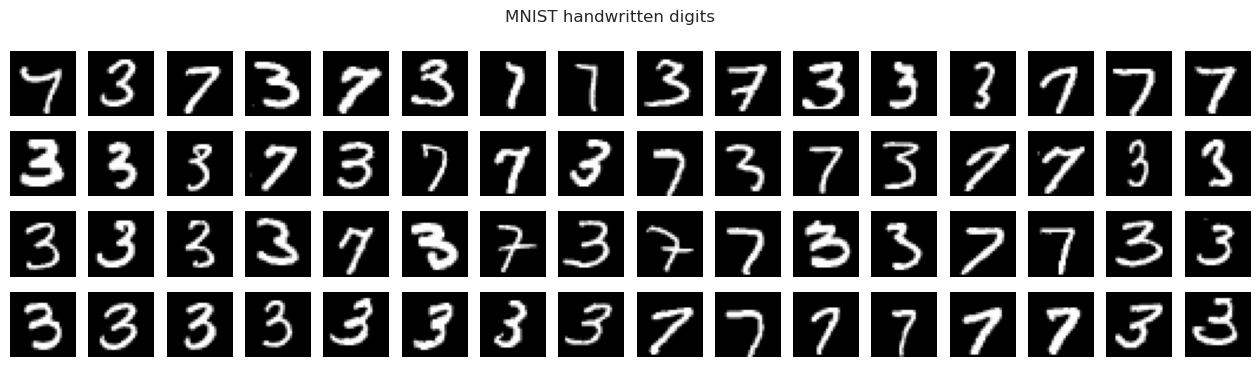

In [9]:
# Plot a batch of MNIST examples
f, axarr = plt.subplots(4, 16, figsize=(16, 4))

# Load a batch of images into memory
images, labels = next(iter(train_loader))

for i, ax in enumerate(axarr.flat):
    ax.imshow(images[i].view(28, 28), cmap="binary_r")
    ax.axis('off')
    
plt.suptitle('MNIST handwritten digits')
plt.show()

### Building the model
When defining the model the latent layer $z$ must act as a bottleneck of information. We initialize the AE with 1 hidden layer in the encoder and decoder using ReLU units as nonlinearities. The latent layer has a dimensionality of 2 in order to make it easy to visualise. Since $x$ are pixel intensities that are normalized between 0 and 1, we use the sigmoid nonlinearity to model the reconstruction.

In [21]:
import torch.nn as nn

def make_mlp(sizes, act):
    layers = []
    for i in range(len(sizes)-1):
        layers += [nn.Linear(sizes[i], sizes[i+1])]
        if i < len(sizes)-2:  # no activation on last linear
            layers += [act()]
    return nn.Sequential(*layers)

class AutoEncoder(nn.Module):
    def __init__(self, hidden_sizes=(256,128), latent_features=2, act=nn.ReLU, use_sigmoid_out=True):
        super().__init__()
        in_dim = 28*28
        self.encoder = make_mlp([in_dim] + list(hidden_sizes) + [latent_features], act)
        self.decoder_core = make_mlp([latent_features] + list(hidden_sizes)[::-1] + [in_dim], act)
        self.use_sigmoid_out = use_sigmoid_out

    def forward(self, x):
        z = self.encoder(x)
        x_logits = self.decoder_core(z)
        x_hat = torch.sigmoid(x_logits) if self.use_sigmoid_out else x_logits
        return {"z": z, "x_hat": x_hat, "x_logits": x_logits}




Following we define the PyTorch functions for training and evaluation.

In [23]:
import torch.optim as optim
#define device
device = torch.device("cuda" if cuda else "cpu")

net = AutoEncoder(hidden_sizes=(256,128), latent_features=2, act=nn.ReLU, use_sigmoid_out=True).to(device)
if cuda:
    net = net.cuda()

print(net)


optimizer = optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)  # weight_decay = L2

# We will use pixel wise mean-squared error as our loss function
loss_function = nn.MSELoss()

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
  (decoder_core): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
  )
)


We can test the forward pass by checking whether the output shape is the same as the as the input.

In [24]:
# test the forward pass
# expect output size of [32, num_features]
x, y = next(iter(train_loader))
print(f"x.shape = {x.shape}")

if cuda:
    x = x.cuda()

outputs = net(x)
print(f"x_hat.shape = {outputs['x_hat'].shape}")


x.shape = torch.Size([64, 784])
x_hat.shape = torch.Size([64, 784])


In the training loop we sample each batch and evaluate the error, latent space, and reconstructions on every epoch.

**NOTE** this will take a while on CPU.

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


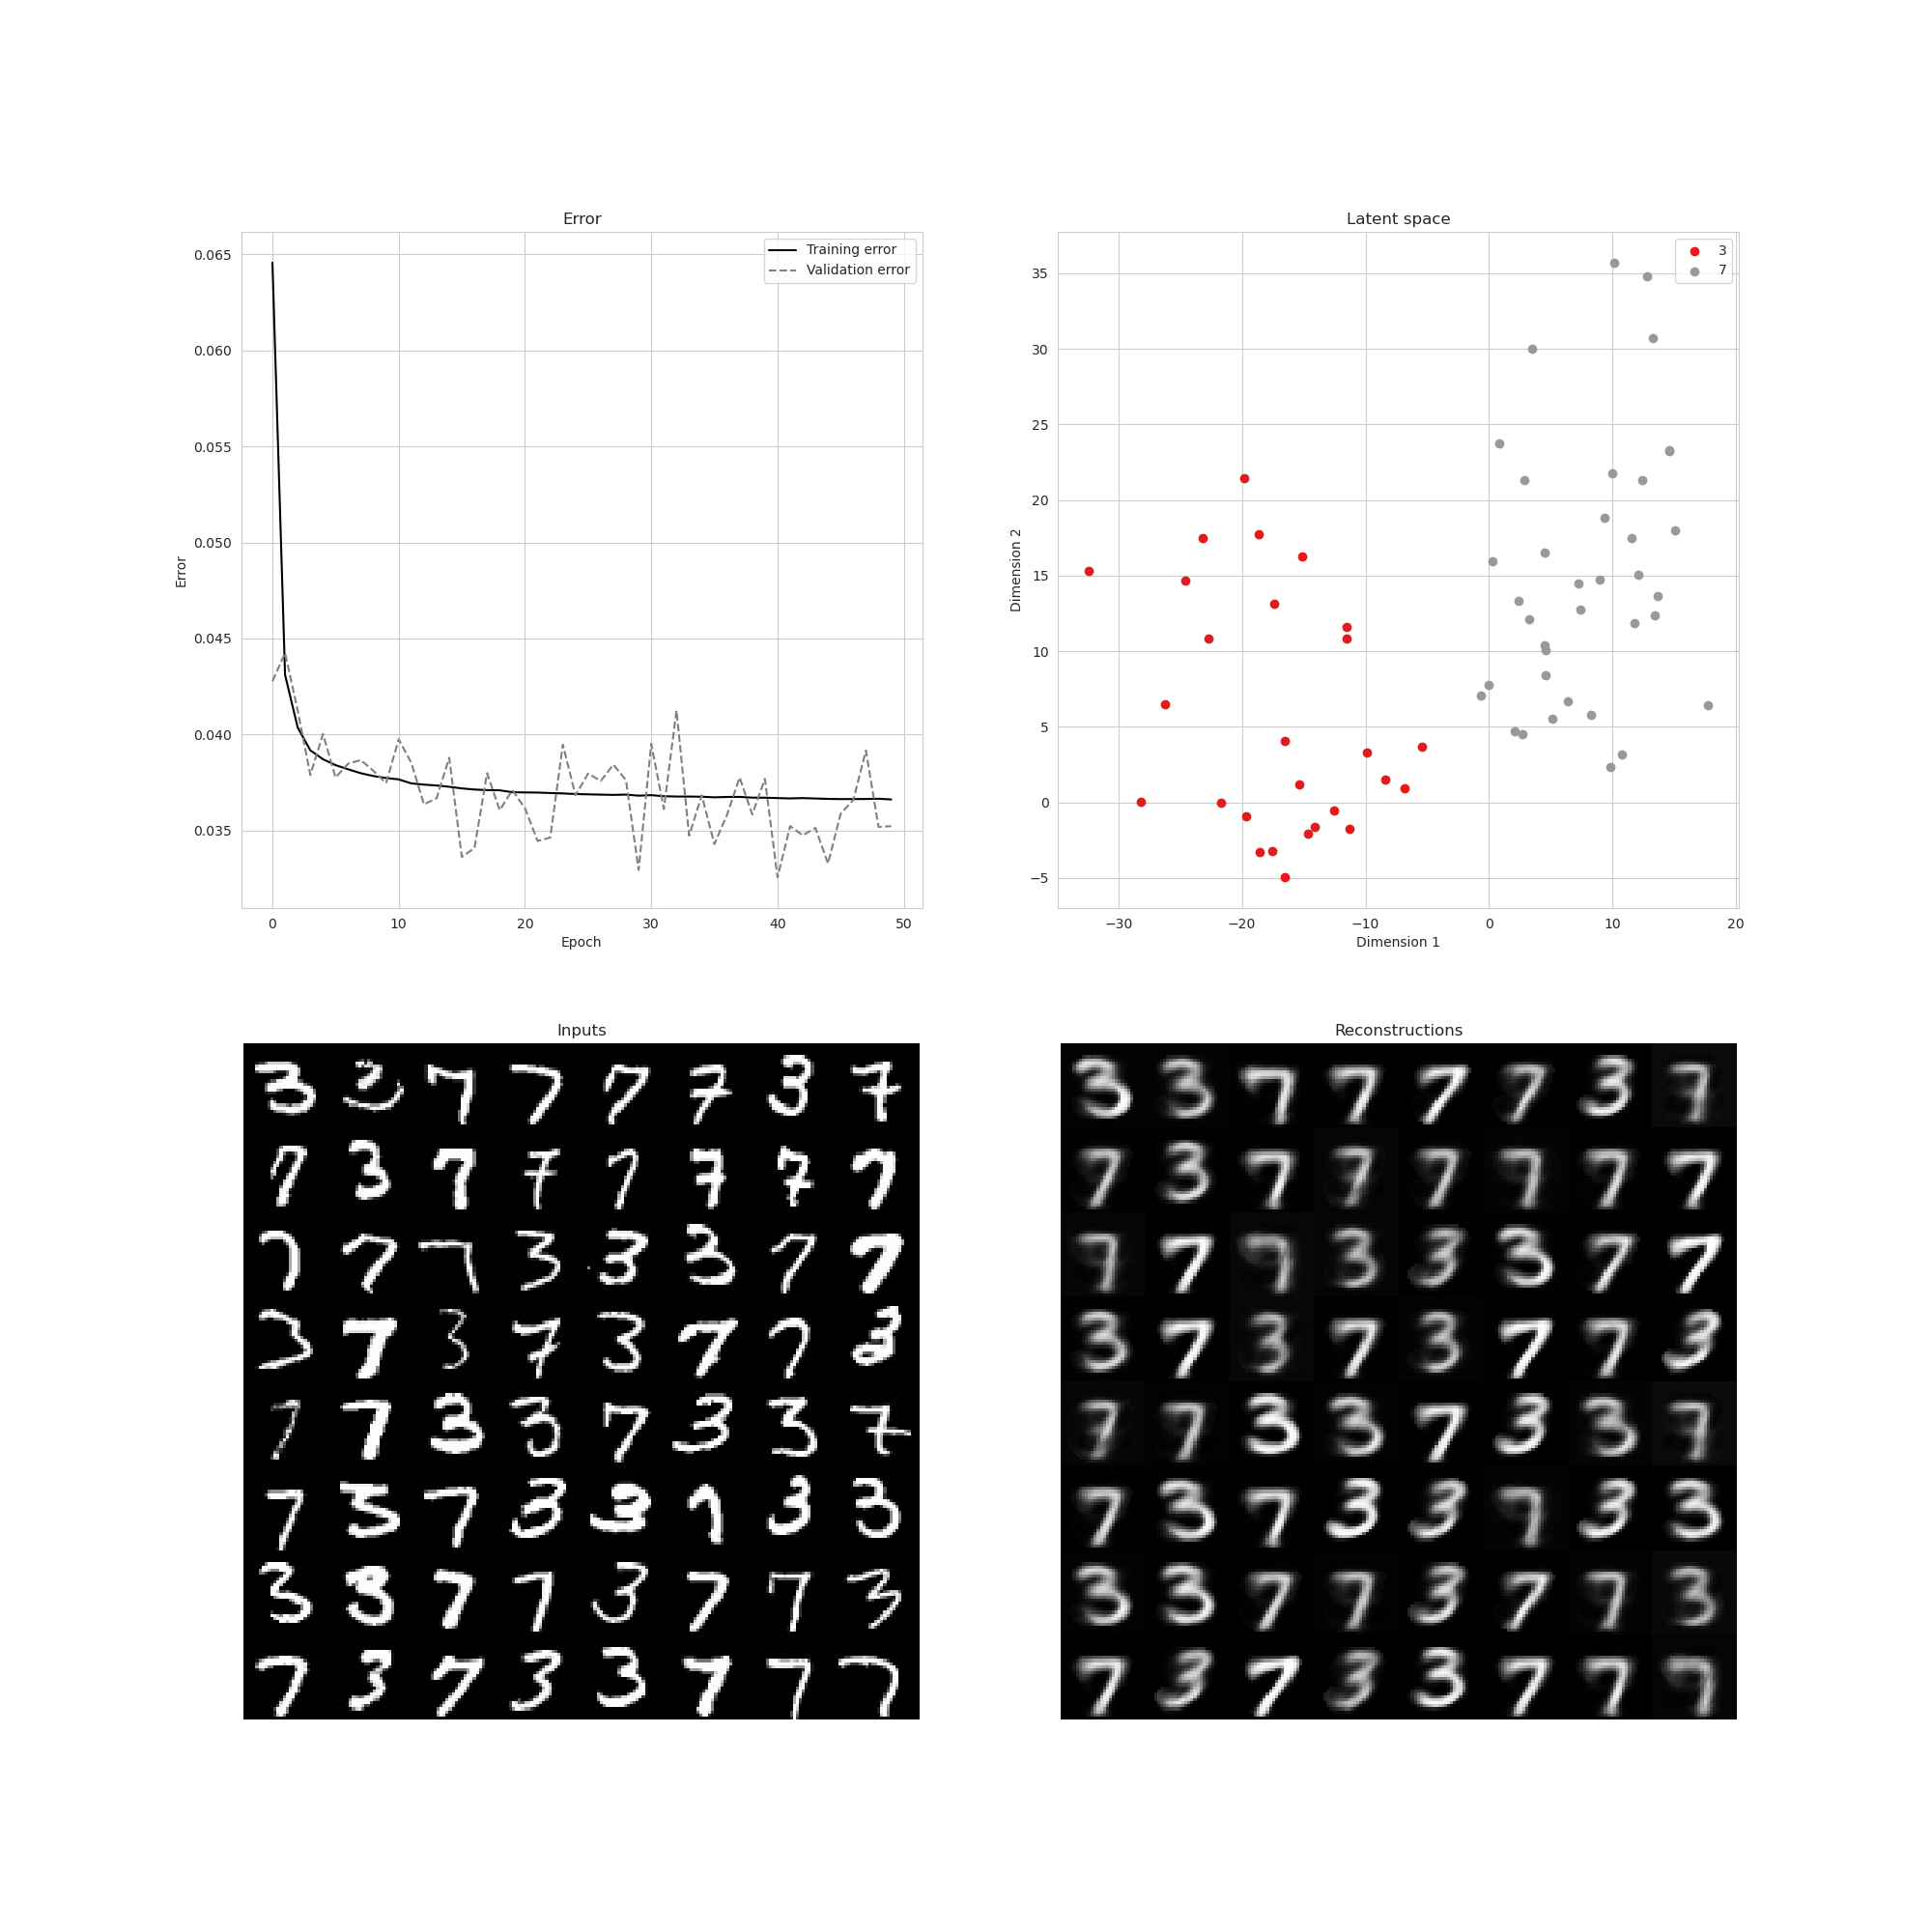

In [25]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

num_epochs = 50

train_loss = []
valid_loss = []

for epoch in range(num_epochs):
    batch_loss = []
    net.train()
    
    # Go through each batch in the training dataset using the loader
    # Note that y is not necessarily known as it is here
    for x, y in train_loader:
        
        if cuda:
            x = x.cuda()
        
        outputs = net(x)
        x_hat = outputs['x_hat']

        # note, target is the original tensor, as we're working with auto-encoders
        loss = loss_function(x_hat, x)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_loss.append(loss.item())

    train_loss.append(np.mean(batch_loss))

    # Evaluate, do not propagate gradients
    with torch.no_grad():
        net.eval()
        
        # Just load a single batch from the test loader
        x, y = next(iter(test_loader))
        
        if cuda:
            x = x.cuda()
        
        outputs = net(x)

        # We save the latent variable and reconstruction for later use
        # we will need them on the CPU to plot
        x_hat = outputs['x_hat']
        z = outputs['z'].cpu().numpy()

        loss = loss_function(x_hat, x)

        valid_loss.append(loss.item())
    
    if epoch == 0:
        continue

    # live plotting of the trainig curves and representation
    plot_autoencoder_stats(x=x.cpu(),
                           x_hat=x_hat.cpu(),
                           z=z,
                           y=y,
                           train_loss=train_loss,
                           valid_loss=valid_loss,
                           epoch=epoch,
                           classes=classes,
                           dimensionality_reduction_op=None)
    
   

# Exercises

## Exercise 1: Analyzing the AE
1. The above implementation of an AE is very simple.
    - Experiment with the number of layers and try different non-linearities in order to improve the reconstructions
    - What happens with the network when we change the non-linearities in the latent layer (e.g. sigmoid)?
    - Try to increase the number of digit classes in the training set and analyze the results
    - Test different optimization algorithms such as ADAM and RMSProp and decide whether you should use regularizers
       
2. Currently we optimize w.r.t. mean squared error. 
    - Find another error function that could fit this problem better
    - Evaluate whether the similarity function $d$ is a better choice and explain your findings

3. Complexity of the bottleneck.
    - Increase the number of units in the latent layer and train
    - Visualize by using [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) or [t-SNE](http://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

## Exercises 2: Adding classification for semi-supervised learning

The above training has been performed unsupervised. Now let us assume that we only have a fraction of labeled data points from each class. As we know, semi-supervised learning can be utilized by combining unsupervised and supervised learning. Now you must analyze whether a trained AE from the above exercise can aid a classifier.

1. Build a simple classifier (like the ones from week1) where you:
    - Train on the labeled dataset and evaluate the results
2. Build a second classifier and train on the latent output $\mathbf{z}$ of the AE.
3. Build a third classifier and train on the reconstructions of the AE.
4. Evaluate the classifiers against each other and implement a model that improves the classification by combining the input, latent output, and reconstruction.

Below we provide some starting code for using only a subset of the labelled data.

In [28]:
def uniform_stratified_sampler(labels, classes, n=None):
    """
    Stratified sampler that distributes labels uniformly by
    sampling at most n data points per class
    """
    from functools import reduce
    # Only choose digits in n_labels
    (indices,) = np.where(reduce(lambda x, y: x | y, [labels.numpy() == i for i in classes]))

    # Ensure uniform distribution of labels
    np.random.shuffle(indices)
    indices = np.hstack([list(filter(lambda idx: labels[idx] == i, indices))[:n] for i in classes])

    indices = torch.from_numpy(indices)
    sampler = SubsetRandomSampler(indices)
    return sampler


batch_size = 64

# Specify how many labelled examples we want per digit class
labels_per_class = 10

# Large pool of unlabelled data
unlabelled = DataLoader(dset_train, batch_size=batch_size, 
                        sampler=stratified_sampler(dset_train.train_labels, classes=classes), pin_memory=cuda)

# Smaller pool of labelled data
labelled = DataLoader(dset_train, batch_size=batch_size,
                      sampler=uniform_stratified_sampler(dset_train.train_labels, classes=classes, n=labels_per_class),
                      pin_memory=cuda)

/zhome/3b/1/169159/.local/lib/python3.9/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


In [29]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if cuda else 'cpu')  # reuse your 'cuda' flag
num_features = 28*28
num_classes = 10  # adjust if you’re using a subset

class Classifier(nn.Module):
    def __init__(self, in_dim=num_features, hidden=256, out_dim=num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, x):
        return self.net(x)

clf_raw = Classifier(in_dim=num_features).to(device)
opt_raw  = optim.Adam(clf_raw.parameters(), lr=1e-3, weight_decay=1e-4)
crit_ce  = nn.CrossEntropyLoss()

def train_one_epoch_classifier(model, opt, loader):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in loader:
        xb = xb.view(xb.size(0), -1).to(device)   # flatten MNIST
        yb = yb.to(device)
        logits = model(xb)
        loss = crit_ce(logits, yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_sum += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    return loss_sum/total, correct/total

@torch.no_grad()
def eval_classifier(model, loader):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in loader:
        xb = xb.view(xb.size(0), -1).to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = crit_ce(logits, yb)
        loss_sum += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    return loss_sum/total, correct/total


In [30]:
num_epochs = 10
for ep in range(1, num_epochs+1):
    tr_loss, tr_acc = train_one_epoch_classifier(clf_raw, opt_raw, labelled)
    te_loss, te_acc = eval_classifier(clf_raw, test_loader)   # assume you have test_loader
    print(f"[Raw] Epoch {ep:02d} | train loss {tr_loss:.3f} acc {tr_acc:.3f} | test loss {te_loss:.3f} acc {te_acc:.3f}")


[Raw] Epoch 01 | train loss 2.343 acc 0.050 | test loss 2.038 acc 0.620
[Raw] Epoch 02 | train loss 1.988 acc 0.700 | test loss 1.764 acc 0.778
[Raw] Epoch 03 | train loss 1.670 acc 0.900 | test loss 1.500 acc 0.850
[Raw] Epoch 04 | train loss 1.395 acc 0.900 | test loss 1.251 acc 0.897
[Raw] Epoch 05 | train loss 1.145 acc 0.950 | test loss 1.023 acc 0.921
[Raw] Epoch 06 | train loss 0.905 acc 0.950 | test loss 0.825 acc 0.937
[Raw] Epoch 07 | train loss 0.700 acc 1.000 | test loss 0.659 acc 0.952
[Raw] Epoch 08 | train loss 0.502 acc 1.000 | test loss 0.524 acc 0.960
[Raw] Epoch 09 | train loss 0.393 acc 1.000 | test loss 0.419 acc 0.965
[Raw] Epoch 10 | train loss 0.295 acc 1.000 | test loss 0.338 acc 0.967


In [35]:
import torch, torch.nn as nn, torch.optim as optim
device = torch.device('cuda' if cuda else 'cpu')

# 1) Freeze AE
net.eval()
for p in net.parameters():
    p.requires_grad_(False)

# 2) Tiny classifier on z
z_dim = net.encoder[-1].out_features  # should be 2 with your current AE
class ClassifierZ(nn.Module):
    def __init__(self, in_dim=z_dim, hidden=64, out_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, z): return self.net(z)

clf_z = ClassifierZ().to(device)
opt_z  = optim.Adam(clf_z.parameters(), lr=1e-3, weight_decay=1e-4)
crit   = nn.CrossEntropyLoss()

def train_epoch_Z(model, opt, loader):
    model.train()
    tot=0; correct=0; loss_sum=0.0
    for xb, yb in loader:
        xb = xb.view(xb.size(0), -1).to(device)
        yb = yb.to(device)
        with torch.no_grad():
            z = net.encoder(xb)
        logits = model(z)
        loss = crit(logits, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        loss_sum += loss.item()*xb.size(0)
        correct  += (logits.argmax(1)==yb).sum().item()
        tot      += xb.size(0)
    return loss_sum/tot, correct/tot

@torch.no_grad()
def eval_Z(model, loader):
    model.eval()
    tot=0; correct=0; loss_sum=0.0
    for xb, yb in loader:
        xb = xb.view(xb.size(0), -1).to(device)
        yb = yb.to(device)
        z  = net.encoder(xb)
        logits = model(z)
        loss = crit(logits, yb)
        loss_sum += loss.item()*xb.size(0)
        correct  += (logits.argmax(1)==yb).sum().item()
        tot      += xb.size(0)
    return loss_sum/tot, correct/tot

# 3) Train a few epochs (same as baseline for fair compare)
for ep in range(1, 11):
    tr_loss, tr_acc = train_epoch_Z(clf_z, opt_z, labelled)
    te_loss, te_acc = eval_Z(clf_z, test_loader)
    print(f"[Z] Epoch {ep:02d} | train loss {tr_loss:.3f} acc {tr_acc:.3f} | test loss {te_loss:.3f} acc {te_acc:.3f}")


[Z] Epoch 01 | train loss 11.491 acc 0.050 | test loss 9.477 acc 0.085
[Z] Epoch 02 | train loss 10.982 acc 0.050 | test loss 9.020 acc 0.102
[Z] Epoch 03 | train loss 10.477 acc 0.050 | test loss 8.568 acc 0.118
[Z] Epoch 04 | train loss 9.975 acc 0.050 | test loss 8.123 acc 0.129
[Z] Epoch 05 | train loss 9.476 acc 0.050 | test loss 7.684 acc 0.144
[Z] Epoch 06 | train loss 8.982 acc 0.050 | test loss 7.253 acc 0.161
[Z] Epoch 07 | train loss 8.492 acc 0.100 | test loss 6.831 acc 0.184
[Z] Epoch 08 | train loss 8.007 acc 0.100 | test loss 6.417 acc 0.208
[Z] Epoch 09 | train loss 7.528 acc 0.100 | test loss 6.013 acc 0.236
[Z] Epoch 10 | train loss 7.057 acc 0.150 | test loss 5.620 acc 0.263


In [36]:
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if cuda else 'cpu')
z_dim = net.encoder[-1].out_features  # latent_features, e.g. 2
num_classes = 10

class ClassifierZ(nn.Module):
    def __init__(self, in_dim=z_dim, hidden=64, out_dim=num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, z):
        return self.net(z)

clf_z = ClassifierZ().to(device)

criterion_cls   = nn.CrossEntropyLoss()
criterion_recon = nn.MSELoss()  # or BCEWithLogitsLoss as we discussed
lambda_recon    = 1.0           # you will tune this (e.g. 0.1, 1, 10)

# joint optimizer: AE + classifier
optimizer = optim.Adam(
    list(net.parameters()) + list(clf_z.parameters()),
    lr=1e-3, weight_decay=1e-4
)


In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from itertools import cycle

device = torch.device('cuda' if cuda else 'cpu')

# z-classifier (reuse if you already made one)
z_dim = net.encoder[-1].out_features  # e.g., 2
num_classes = 10

class ClassifierZ(nn.Module):
    def __init__(self, in_dim=z_dim, hidden=64, out_dim=num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, z): return self.net(z)

clf_z = ClassifierZ().to(device)

criterion_cls   = nn.CrossEntropyLoss()
criterion_recon = nn.MSELoss()              # since net returns sigmoid(x) in x_hat
lambda_recon    = 1.0                       # try 0.1 / 1 / 5 later

optimizer = optim.Adam(
    list(net.parameters()) + list(clf_z.parameters()),
    lr=1e-3, weight_decay=1e-4
)

@torch.no_grad()
def eval_z_acc(model, ae, loader):
    model.eval(); ae.eval()
    total = 0; correct = 0
    for xb, yb in loader:
        xb = xb.view(xb.size(0), -1).to(device)
        yb = yb.to(device)
        z  = ae.encoder(xb)
        logits = model(z)
        preds = logits.argmax(1)
        correct += (preds == yb).sum().item()
        total   += xb.size(0)
    return correct / total

# --- joint training ---
num_epochs = 10
for epoch in range(1, num_epochs+1):
    net.train(); clf_z.train()
    cls_sum = rec_sum = 0.0; n = 0

    for (x, y), (u, _) in zip(cycle(labelled), unlabelled):
        x = x.view(x.size(0), -1).to(device); y = y.to(device)
        u = u.view(u.size(0), -1).to(device)

        out_x = net(x); z_x = out_x['z']
        logits = clf_z(z_x)
        loss_cls = criterion_cls(logits, y)

        out_u = net(u)
        loss_recon = criterion_recon(out_u['x_hat'], u)

        loss = loss_cls + lambda_recon * loss_recon

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        cls_sum += loss_cls.item(); rec_sum += loss_recon.item(); n += 1

    test_acc = eval_z_acc(clf_z, net, test_loader)
    print(f"[SemiSup] Epoch {epoch:02d} | L_cls {cls_sum/n:.3f} | L_rec {rec_sum/n:.3f} | test_acc {test_acc:.3f}")


[SemiSup] Epoch 01 | L_cls 0.254 | L_rec 0.037 | test_acc 0.950
[SemiSup] Epoch 02 | L_cls 0.014 | L_rec 0.037 | test_acc 0.942
[SemiSup] Epoch 03 | L_cls 0.006 | L_rec 0.037 | test_acc 0.941
[SemiSup] Epoch 04 | L_cls 0.003 | L_rec 0.037 | test_acc 0.940
[SemiSup] Epoch 05 | L_cls 0.002 | L_rec 0.037 | test_acc 0.940
[SemiSup] Epoch 06 | L_cls 0.001 | L_rec 0.037 | test_acc 0.941
[SemiSup] Epoch 07 | L_cls 0.001 | L_rec 0.037 | test_acc 0.941
[SemiSup] Epoch 08 | L_cls 0.001 | L_rec 0.037 | test_acc 0.941
[SemiSup] Epoch 09 | L_cls 0.001 | L_rec 0.037 | test_acc 0.942
[SemiSup] Epoch 10 | L_cls 0.000 | L_rec 0.037 | test_acc 0.942
